Name:Parth Shantaram Korgaonkar
Roll No.: Cs26
Batch: Cs-2

In [1]:
# Task 1: Import Required Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Task 2: Load Auto MPG Dataset

df = pd.read_csv('/content/auto-mpg.csv')

print("Auto MPG dataset loaded successfully!")

Auto MPG dataset loaded successfully!


In [3]:
# Task 3: Inspect Dataset

print("First 5 rows:")
display(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

First 5 rows:


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino



Dataset Shape:
(398, 9)

Column Names:
['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model year', 'origin', 'car name']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


In [4]:
# Task 4: Check Missing/Invalid Values

print("Missing values:")
print(df.isnull().sum())

print("\nUnique horsepower values containing '?':")
print(df[df['horsepower'] == '?'].shape)

Missing values:
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64

Unique horsepower values containing '?':
(6, 9)


In [5]:
# Convert horsepower to numeric
# Invalid values such as '?' become NaN

df['horsepower'] = pd.to_numeric(
    df['horsepower'],
    errors='coerce'
)

print("Missing values after converting horsepower:")
print(df.isnull().sum())

Missing values after converting horsepower:
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64


In [6]:
# Remove rows with missing horsepower

df = df.dropna(subset=['horsepower']).reset_index(drop=True)

print("Dataset shape after cleaning:")
print(df.shape)

print("\nMissing values after cleaning:")
print(df[['mpg', 'horsepower']].isnull().sum())

Dataset shape after cleaning:
(392, 9)

Missing values after cleaning:
mpg           0
horsepower    0
dtype: int64


In [7]:
# Task 5: Select Horsepower and MPG

X = df['horsepower'].values
y = df['mpg'].values

print("Input feature: Horsepower")
print("Target variable: MPG")

print("\nX shape:", X.shape)
print("y shape:", y.shape)

print("\nFirst 10 Horsepower values:")
print(X[:10])

print("\nFirst 10 MPG values:")
print(y[:10])

Input feature: Horsepower
Target variable: MPG

X shape: (392,)
y shape: (392,)

First 10 Horsepower values:
[130. 165. 150. 150. 140. 198. 220. 215. 225. 190.]

First 10 MPG values:
[18. 15. 18. 16. 17. 15. 14. 14. 14. 15.]


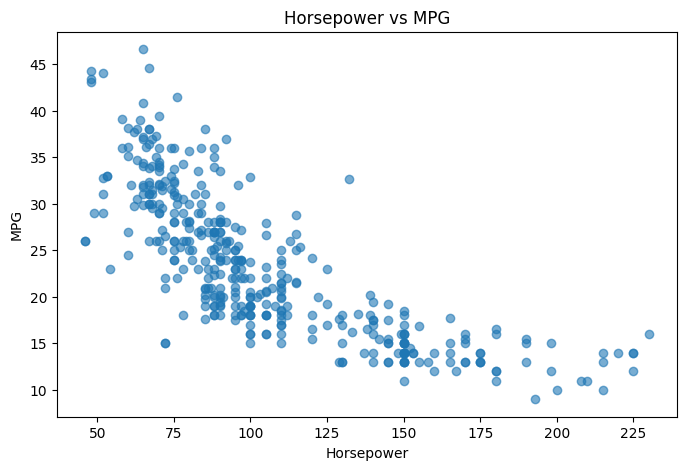

In [8]:
# Task 6: Horsepower vs MPG Scatter Plot

plt.figure(figsize=(8, 5))

plt.scatter(
    X,
    y,
    alpha=0.6
)

plt.xlabel('Horsepower')
plt.ylabel('MPG')
plt.title('Horsepower vs MPG')

plt.show()

In [9]:
# Task 7: Add Bias / Intercept Term

X_matrix = np.column_stack([
    np.ones(len(X)),
    X
])

print("Feature matrix shape:")
print(X_matrix.shape)

print("\nFirst 5 rows of X matrix:")
print(X_matrix[:5])

Feature matrix shape:
(392, 2)

First 5 rows of X matrix:
[[  1. 130.]
 [  1. 165.]
 [  1. 150.]
 [  1. 150.]
 [  1. 140.]]


In [10]:
# Task 8: Compute Correlation

correlation = np.corrcoef(
    X,
    y
)[0, 1]

print("Correlation between Horsepower and MPG:")
print(correlation)

Correlation between Horsepower and MPG:
-0.7784267838977756


In [11]:
# Task 9: Calculate OLS Weights

def ols(X, y):

    # Transpose of X
    X_T = X.T

    # Calculate X^T X
    XTX = X_T @ X

    # Calculate X^T y
    XTy = X_T @ y

    # Calculate inverse of X^T X
    XTX_inverse = np.linalg.inv(XTX)

    # Calculate beta
    beta = XTX_inverse @ XTy

    return beta


# Calculate OLS coefficients
beta = ols(X_matrix, y)

print("OLS coefficients:")
print(beta)

print("\nIntercept (β0):", beta[0])
print("Slope (β1):", beta[1])

OLS coefficients:
[39.93586102 -0.15784473]

Intercept (β0): 39.93586102117056
Slope (β1): -0.1578447333536543


In [12]:
# Task 10: Predict MPG

y_pred = X_matrix @ beta

print("First 10 actual MPG values:")
print(y[:10])

print("\nFirst 10 predicted MPG values:")
print(y_pred[:10])

First 10 actual MPG values:
[18. 15. 18. 16. 17. 15. 14. 14. 14. 15.]

First 10 predicted MPG values:
[19.41604569 13.89148002 16.25915102 16.25915102 17.83759835  8.68260382
  5.21001968  5.99924335  4.42079602  9.94536168]


In [13]:
# Actual vs Predicted MPG

comparison = pd.DataFrame({
    'Actual MPG': y,
    'Predicted MPG': y_pred
})

display(comparison.head(10))

,Actual MPG,Predicted MPG
0,18.0,19.416046
1,15.0,13.891480
2,18.0,16.259151
3,16.0,16.259151
4,17.0,17.837598
5,15.0,8.682604
6,14.0,5.210020
7,14.0,5.999243
8,14.0,4.420796
9,15.0,9.945362


In [14]:
# Task 11: Calculate Residuals

residuals = y - y_pred

print("First 10 residuals:")
print(residuals[:10])

First 10 residuals:
[-1.41604569  1.10851998  1.74084898 -0.25915102 -0.83759835  6.31739618
  8.78998032  8.00075665  9.57920398  5.05463832]


In [15]:
# Task 12: Calculate SSE, MSE and R²

# Sum of Squared Errors
SSE = np.sum(residuals ** 2)

# Mean Squared Error
MSE = np.mean(residuals ** 2)

# Total Sum of Squares
TSS = np.sum(
    (y - np.mean(y)) ** 2
)

# R²
R2 = 1 - (SSE / TSS)

print("Sum of Squared Errors (SSE):")
print(SSE)

print("\nMean Squared Error (MSE):")
print(MSE)

print("\nR² Score:")
print(R2)

print(f"\nModel explains approximately {R2 * 100:.2f}% of the variation in MPG.")

Sum of Squared Errors (SSE):
9385.915871932419

Mean Squared Error (MSE):
23.943662938603108

R² Score:
0.6059482578894348

Model explains approximately 60.59% of the variation in MPG.


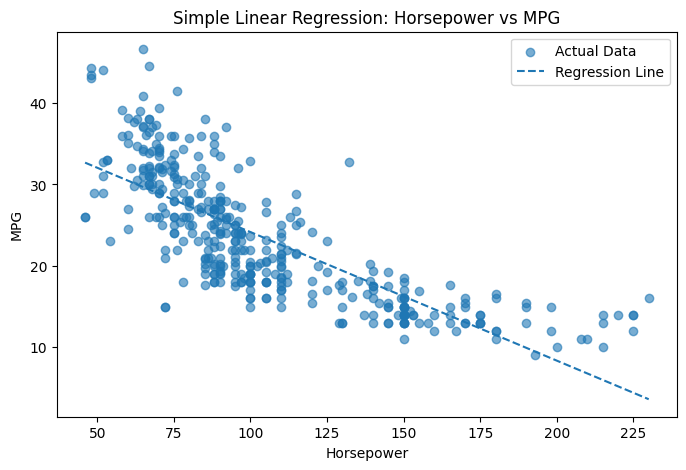

In [16]:
# Task 13: Regression Line

plt.figure(figsize=(8, 5))

plt.scatter(
    X,
    y,
    alpha=0.6,
    label='Actual Data'
)

# Sort X values for a clean regression line
sorted_indices = np.argsort(X)

X_sorted = X[sorted_indices]
y_pred_sorted = y_pred[sorted_indices]

plt.plot(
    X_sorted,
    y_pred_sorted,
    linestyle='--',
    label='Regression Line'
)

plt.xlabel('Horsepower')
plt.ylabel('MPG')
plt.title('Simple Linear Regression: Horsepower vs MPG')

plt.legend()

plt.show()

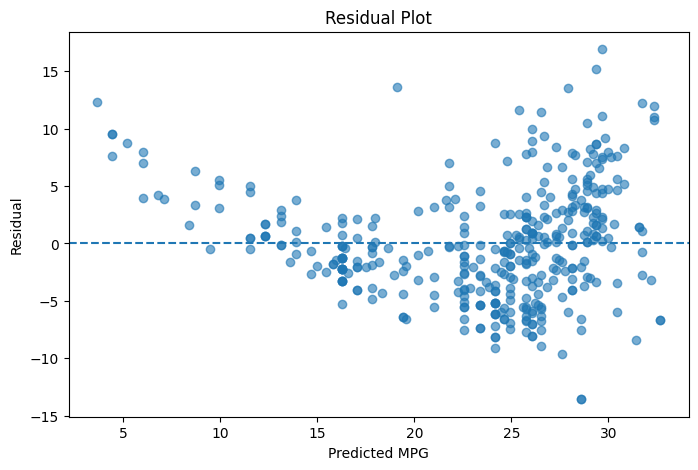

In [17]:
# Task 14: Residual Plot

plt.figure(figsize=(8, 5))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel('Predicted MPG')
plt.ylabel('Residual')
plt.title('Residual Plot')

plt.show()

## Task 15: Interpretation and Conclusion

The Simple Linear Regression model was successfully implemented using the Ordinary Least Squares (OLS) method to predict MPG from Horsepower. The scatter plot and correlation analysis show a negative relationship between Horsepower and MPG, indicating that vehicles with higher horsepower generally tend to have lower fuel efficiency.

The OLS method was used to calculate the intercept and slope coefficients. The model was then used to predict MPG values. Its performance was evaluated using Sum of Squared Errors (SSE), Mean Squared Error (MSE), and R².

The regression line provides a simple representation of the relationship between Horsepower and MPG. The residual plot helps analyze the prediction errors and whether they are reasonably distributed around zero.

### Advantages
- Simple and easy to understand.
- Easy to implement using OLS and NumPy.
- Regression coefficients are easy to interpret.
- Useful for understanding the relationship between one input feature and a continuous target.

### Limitations
- Uses only one predictor, Horsepower.
- Assumes a linear relationship between Horsepower and MPG.
- Sensitive to outliers.
- Cannot capture the effects of other factors such as vehicle weight, displacement, cylinders, and model year.
- More complex models may provide better predictions when multiple factors affect MPG.

### Final Conclusion

The experiment successfully implemented Simple Linear Regression using OLS. Horsepower showed a negative relationship with MPG, and the evaluation metrics were used to measure the predictive performance of the model.